In [ ]:
!pip install yfinance pandas numpy scikit-learn xgboost shap matplotlib torch -q

In [ ]:
import os
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import shap
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

RAW_DATA_DIR = "data/raw"
PROCESSED_DATA_DIR = "data/processed"
os.makedirs(RAW_DATA_DIR, exist_ok=True)
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

START_DATE = "2005-01-01"
END_DATE = "2025-12-31"
HAR_HORIZONS = [1, 5, 22]
TARGET_FORWARD_WINDOW = 22
SPIKE_PERCENTILE = 90

VIX_YF_MAP = {"VIX": "^VIX", "VIX3M": "^VIX3M", "VIX6M": "^VIX6M"}

print("Config loaded.")


Config loaded.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# DATA PIPELINE — Download + Build All Features
# ══════════════════════════════════════════════════════════════════
print("Downloading data...")

# SPX
path = os.path.join(RAW_DATA_DIR, "spx_daily.csv")
if os.path.exists(path):
    spx = pd.read_csv(path, index_col="Date", parse_dates=True)
else:
    spx = yf.download("^GSPC", start=START_DATE, end=END_DATE, auto_adjust=True)
    spx.to_csv(path)
print(f"  SPX: {len(spx)} rows")

# VIX term structure
path = os.path.join(RAW_DATA_DIR, "vix_term_structure.csv")
if os.path.exists(path):
    vix_raw = pd.read_csv(path, index_col="Date", parse_dates=True)
else:
    frames = {}
    for label, ticker in VIX_YF_MAP.items():
        try:
            df = yf.download(ticker, start=START_DATE, end=END_DATE, auto_adjust=True)
            if len(df) > 0: frames[label] = df["Close"].squeeze()
        except: pass
    vix_raw = pd.DataFrame(frames)
    vix_raw.index.name = "Date"
    vix_raw.to_csv(path)
print(f"  VIX: {len(vix_raw)} rows")

close = spx["Close"].squeeze()
high = spx["High"].squeeze()
low = spx["Low"].squeeze()
volume = spx["Volume"].squeeze()
log_ret = np.log(close / close.shift(1))
squared = log_ret ** 2

# ── P5: HAR-RV features ──
feat = pd.DataFrame(index=close.index)
for h in HAR_HORIZONS:
    feat[f"RV_{h}d"] = np.sqrt(squared.rolling(h).sum() * (252 / h))

# ── P2: SPX market features (CLEANED — no redundancy) ──
feat["log_return"] = log_ret
feat["abs_return"] = log_ret.abs()
feat["return_5d"] = close.pct_change(5)
feat["return_22d"] = close.pct_change(22)
feat["vol_5d"] = log_ret.rolling(5).std() * np.sqrt(252)
feat["vol_22d"] = log_ret.rolling(22).std() * np.sqrt(252)
feat["parkinson_vol"] = np.sqrt((1 / (4 * np.log(2))) * (np.log(high / low) ** 2)) * np.sqrt(252)
feat["volume_zscore"] = (volume - volume.rolling(22).mean()) / volume.rolling(22).std()

# RSI
delta = close.diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss_s = (-delta.clip(upper=0)).rolling(14).mean()
feat["rsi_14"] = 100 - (100 / (1 + gain / loss_s))

# ── P1: VIX term structure features (CLEANED — dropped redundant proxies) ──
feat["vix_level"] = vix_raw.get("VIX")
# DROPPED: VIX3M, VIX6M raw levels (redundant with vix_level + slopes)
# DROPPED: atm_iv_proxy (= VIX/100, perfect duplicate)
# DROPPED: skew_proxy (= slope_3m_spot, perfect duplicate)

if "VIX" in vix_raw.columns and "VIX3M" in vix_raw.columns:
    feat["slope_3m_spot"] = vix_raw["VIX3M"] - vix_raw["VIX"]
if "VIX3M" in vix_raw.columns and "VIX6M" in vix_raw.columns:
    feat["slope_6m_3m"] = vix_raw["VIX6M"] - vix_raw["VIX3M"]
if all(c in vix_raw.columns for c in ["VIX", "VIX3M", "VIX6M"]):
    feat["curvature"] = vix_raw["VIX"] - 2 * vix_raw["VIX3M"] + vix_raw["VIX6M"]
if "VIX" in vix_raw.columns and "VIX3M" in vix_raw.columns:
    feat["contango_flag"] = (vix_raw["VIX3M"] > vix_raw["VIX"]).astype(int)

if "VIX" in vix_raw.columns:
    feat["vix_1d_change"] = vix_raw["VIX"].pct_change()
    # DROPPED: vix_5d_change (redundant with vix_momentum_5d)
    feat["vix_zscore_20d"] = (
        (vix_raw["VIX"] - vix_raw["VIX"].rolling(20).mean())
        / vix_raw["VIX"].rolling(20).std()
    )
    feat["vix_ma_ratio"] = vix_raw["VIX"] / vix_raw["VIX"].rolling(60).mean()

# Flow proxies (cleaned)
if "vix_level" in feat.columns:
    feat["vix_momentum_5d"] = feat["vix_level"].pct_change(5)
    feat["vix_momentum_22d"] = feat["vix_level"].pct_change(22)
    feat["vix_acceleration"] = feat["vix_momentum_5d"].diff(5)
if "slope_3m_spot" in feat.columns:
    feat["term_slope_change_5d"] = feat["slope_3m_spot"].diff(5)

# ── Targets ──
fwd_rv = []
sq = squared.values
for i in range(len(sq)):
    end = i + 1 + TARGET_FORWARD_WINDOW
    if end > len(sq):
        fwd_rv.append(np.nan)
    else:
        fwd_rv.append(np.sqrt(np.sum(sq[i+1:end]) * (252 / TARGET_FORWARD_WINDOW)))

feat["fwd_rv_22d"] = fwd_rv
feat = feat.dropna()

threshold = np.percentile(feat["fwd_rv_22d"], SPIKE_PERCENTILE)
feat["spike_label"] = (feat["fwd_rv_22d"] > threshold).astype(int)

target_cols = ["fwd_rv_22d", "spike_label"]
feature_cols = [c for c in feat.columns if c not in target_cols]

print(f"\nFinal dataset: {feat.shape[0]} rows x {len(feature_cols)} features")
print(f"Date range: {feat.index.min().date()} to {feat.index.max().date()}")
print(f"Spike threshold: {threshold:.4f}")
print(f"Spikes: {feat['spike_label'].sum()} / {len(feat)}")
print(f"\nFeatures ({len(feature_cols)}):")
for i, c in enumerate(feature_cols):
    print(f"  {i+1:2d}. {c}")
print(f"\nDropped vs V1: VIX3M, VIX6M, VIX raw, atm_iv_proxy, skew_proxy, vix_5d_change")


[*********************100%***********************]  1 of 1 completed


  SPX: 5282 rows


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


  VIX: 5282 rows

Final dataset: 4506 rows x 24 features
Date range: 2008-01-02 to 2025-11-26
Spike threshold: 0.2809
Spikes: 451 / 4506

Features (24):
   1. RV_1d
   2. RV_5d
   3. RV_22d
   4. log_return
   5. abs_return
   6. return_5d
   7. return_22d
   8. vol_5d
   9. vol_22d
  10. parkinson_vol
  11. volume_zscore
  12. rsi_14
  13. vix_level
  14. slope_3m_spot
  15. slope_6m_3m
  16. curvature
  17. contango_flag
  18. vix_1d_change
  19. vix_zscore_20d
  20. vix_ma_ratio
  21. vix_momentum_5d
  22. vix_momentum_22d
  23. vix_acceleration
  24. term_slope_change_5d

Dropped vs V1: VIX3M, VIX6M, VIX raw, atm_iv_proxy, skew_proxy, vix_5d_change


In [ ]:
# ══════════════════════════════════════════════════════════════════
# WALK-FORWARD CROSS-VALIDATION
# ══════════════════════════════════════════════════════════════════
# Train on expanding window, test on next year.
# Much more robust than a single train/test split.

har_cols = ["RV_1d", "RV_5d", "RV_22d"]

# Define folds: train up to year Y, test on year Y
test_years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

wf_results = []

for test_year in test_years:
    train_mask = feat.index.year < test_year
    test_mask = feat.index.year == test_year

    if train_mask.sum() < 500 or test_mask.sum() < 50:
        continue

    X_tr = feat.loc[train_mask, feature_cols]
    y_tr_reg = feat.loc[train_mask, "fwd_rv_22d"]
    y_tr_cls = feat.loc[train_mask, "spike_label"]
    X_te = feat.loc[test_mask, feature_cols]
    y_te_reg = feat.loc[test_mask, "fwd_rv_22d"]
    y_te_cls = feat.loc[test_mask, "spike_label"]

    # --- HAR-RV Linear ---
    har = LinearRegression().fit(X_tr[har_cols], y_tr_reg)
    har_p = har.predict(X_te[har_cols])
    har_mse = mean_squared_error(y_te_reg, har_p)
    har_auc = roc_auc_score(y_te_cls, har_p) if y_te_cls.nunique() > 1 else np.nan

    # --- XGBoost Regressor (all features) ---
    xgb_reg = xgb.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbosity=0,
    )
    xgb_reg.fit(X_tr, y_tr_reg)
    xgb_reg_p = xgb_reg.predict(X_te)
    xgb_reg_mse = mean_squared_error(y_te_reg, xgb_reg_p)
    xgb_reg_auc = roc_auc_score(y_te_cls, xgb_reg_p) if y_te_cls.nunique() > 1 else np.nan

    # --- XGBoost Classifier (separate model for spike detection) ---
    # Scale positive class weight by imbalance ratio
    pos_weight = (y_tr_cls == 0).sum() / max((y_tr_cls == 1).sum(), 1)
    xgb_cls = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7,
        scale_pos_weight=pos_weight,
        random_state=42, verbosity=0, eval_metric="logloss",
    )
    xgb_cls.fit(X_tr, y_tr_cls)
    xgb_cls_prob = xgb_cls.predict_proba(X_te)[:, 1]
    xgb_cls_auc = roc_auc_score(y_te_cls, xgb_cls_prob) if y_te_cls.nunique() > 1 else np.nan

    wf_results.append({
        "Year": test_year,
        "N_test": test_mask.sum(),
        "HAR_MSE": har_mse,
        "HAR_AUC": har_auc,
        "XGB_Reg_MSE": xgb_reg_mse,
        "XGB_Reg_AUC": xgb_reg_auc,
        "XGB_Cls_AUC": xgb_cls_auc,
    })
    print(f"  {test_year}: HAR MSE={har_mse:.5f} AUC={har_auc:.3f} | "
          f"XGB Reg MSE={xgb_reg_mse:.5f} AUC={xgb_reg_auc:.3f} | "
          f"XGB Cls AUC={xgb_cls_auc:.3f}")

wf_df = pd.DataFrame(wf_results).set_index("Year")
print("\n" + "=" * 70)
print("WALK-FORWARD AVERAGES")
print("=" * 70)
print(f"  HAR-RV Linear      MSE={wf_df['HAR_MSE'].mean():.6f}   AUC={wf_df['HAR_AUC'].mean():.3f}")
print(f"  XGB Regressor      MSE={wf_df['XGB_Reg_MSE'].mean():.6f}   AUC={wf_df['XGB_Reg_AUC'].mean():.3f}")
print(f"  XGB Classifier     AUC={wf_df['XGB_Cls_AUC'].mean():.3f}")


  2015: HAR MSE=0.00397 AUC=0.281 | XGB Reg MSE=0.00535 AUC=0.383 | XGB Cls AUC=0.228
  2016: HAR MSE=0.00310 AUC=nan | XGB Reg MSE=0.00290 AUC=nan | XGB Cls AUC=nan
  2017: HAR MSE=0.00103 AUC=nan | XGB Reg MSE=0.00255 AUC=nan | XGB Cls AUC=nan
  2018: HAR MSE=0.00536 AUC=0.793 | XGB Reg MSE=0.00583 AUC=0.734 | XGB Cls AUC=0.848
  2019: HAR MSE=0.00343 AUC=nan | XGB Reg MSE=0.00297 AUC=nan | XGB Cls AUC=nan
  2020: HAR MSE=0.04569 AUC=0.718 | XGB Reg MSE=0.04156 AUC=0.645 | XGB Cls AUC=0.706
  2021: HAR MSE=0.00204 AUC=nan | XGB Reg MSE=0.00159 AUC=nan | XGB Cls AUC=nan
  2022: HAR MSE=0.00385 AUC=0.582 | XGB Reg MSE=0.00516 AUC=0.568 | XGB Cls AUC=0.437
  2023: HAR MSE=0.00109 AUC=nan | XGB Reg MSE=0.00069 AUC=nan | XGB Cls AUC=nan
  2024: HAR MSE=0.00185 AUC=nan | XGB Reg MSE=0.00260 AUC=nan | XGB Cls AUC=nan
  2025: HAR MSE=0.01020 AUC=0.867 | XGB Reg MSE=0.01210 AUC=0.855 | XGB Cls AUC=0.756

WALK-FORWARD AVERAGES
  HAR-RV Linear      MSE=0.007417   AUC=0.648
  XGB Regressor      

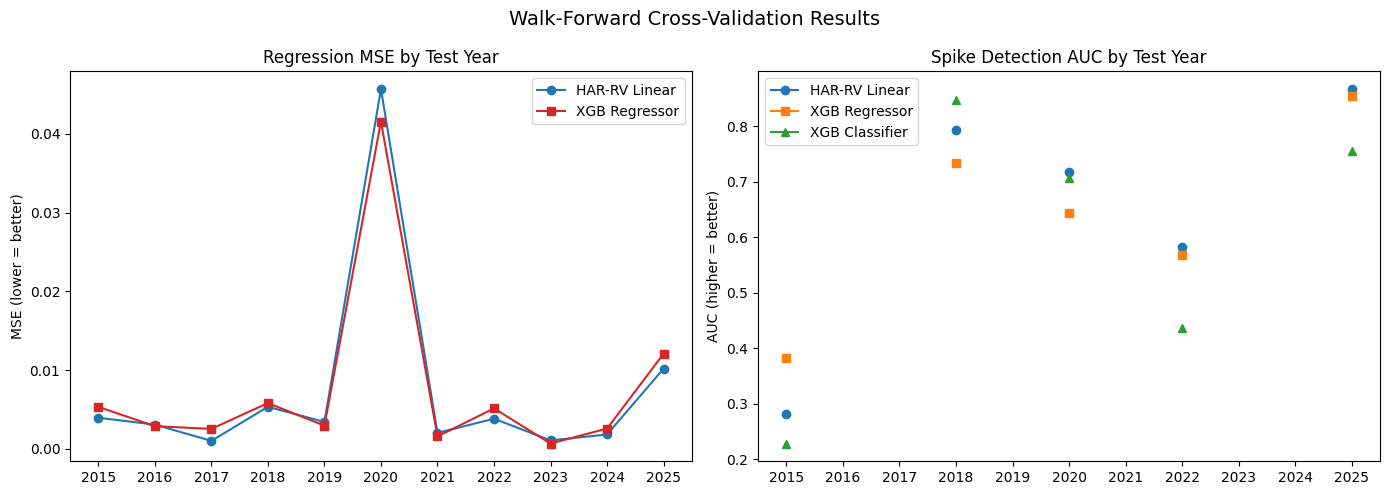


Note: 2020 is the COVID stress test. Performance there tells you
how each model handles unprecedented tail events.


In [ ]:
# ── Walk-forward results by year ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(wf_df.index, wf_df["HAR_MSE"], "o-", label="HAR-RV Linear", color="tab:blue")
ax.plot(wf_df.index, wf_df["XGB_Reg_MSE"], "s-", label="XGB Regressor", color="tab:red")
ax.set_ylabel("MSE (lower = better)")
ax.set_title("Regression MSE by Test Year")
ax.legend()
ax.set_xticks(wf_df.index)

ax = axes[1]
ax.plot(wf_df.index, wf_df["HAR_AUC"], "o-", label="HAR-RV Linear", color="tab:blue")
ax.plot(wf_df.index, wf_df["XGB_Reg_AUC"], "s-", label="XGB Regressor", color="tab:orange")
ax.plot(wf_df.index, wf_df["XGB_Cls_AUC"], "^-", label="XGB Classifier", color="tab:green")
ax.set_ylabel("AUC (higher = better)")
ax.set_title("Spike Detection AUC by Test Year")
ax.legend()
ax.set_xticks(wf_df.index)

plt.suptitle("Walk-Forward Cross-Validation Results", fontsize=14)
plt.tight_layout()
plt.show()

print("\nNote: 2020 is the COVID stress test. Performance there tells you")
print("how each model handles unprecedented tail events.")


In [ ]:
# ══════════════════════════════════════════════════════════════════
# FINAL MODELS — Train pre-2020, test 2020+ (for SHAP and plots)
# ══════════════════════════════════════════════════════════════════
SPLIT = "2020-01-01"
train = feat[feat.index < SPLIT]
test = feat[feat.index >= SPLIT]

X_train = train[feature_cols]; X_test = test[feature_cols]
y_train_reg = train["fwd_rv_22d"]; y_test_reg = test["fwd_rv_22d"]
y_train_cls = train["spike_label"]; y_test_cls = test["spike_label"]

# Regressor
xgb_reg_final = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=0,
)
xgb_reg_final.fit(X_train, y_train_reg)
reg_pred = xgb_reg_final.predict(X_test)

# Classifier
pos_w = (y_train_cls == 0).sum() / max((y_train_cls == 1).sum(), 1)
xgb_cls_final = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7,
    scale_pos_weight=pos_w, random_state=42, verbosity=0, eval_metric="logloss",
)
xgb_cls_final.fit(X_train, y_train_cls)
cls_prob = xgb_cls_final.predict_proba(X_test)[:, 1]
cls_pred = xgb_cls_final.predict(X_test)

print("FINAL MODEL PERFORMANCE (test: 2020+)")
print("=" * 55)
print(f"  Regressor MSE:  {mean_squared_error(y_test_reg, reg_pred):.6f}")
print(f"  Regressor MAE:  {mean_absolute_error(y_test_reg, reg_pred):.6f}")
print(f"  Regressor AUC:  {roc_auc_score(y_test_cls, reg_pred):.4f}")
print(f"  Classifier AUC: {roc_auc_score(y_test_cls, cls_prob):.4f}")
print(f"\nClassifier Report:")
print(classification_report(y_test_cls, cls_pred, target_names=["Calm", "Spike"]))


FINAL MODEL PERFORMANCE (test: 2020+)
  Regressor MSE:  0.010268
  Regressor MAE:  0.055374
  Regressor AUC:  0.7851
  Classifier AUC: 0.7149

Classifier Report:
              precision    recall  f1-score   support

        Calm       0.93      0.95      0.94      1344
       Spike       0.38      0.28      0.32       141

    accuracy                           0.89      1485
   macro avg       0.65      0.61      0.63      1485
weighted avg       0.87      0.89      0.88      1485



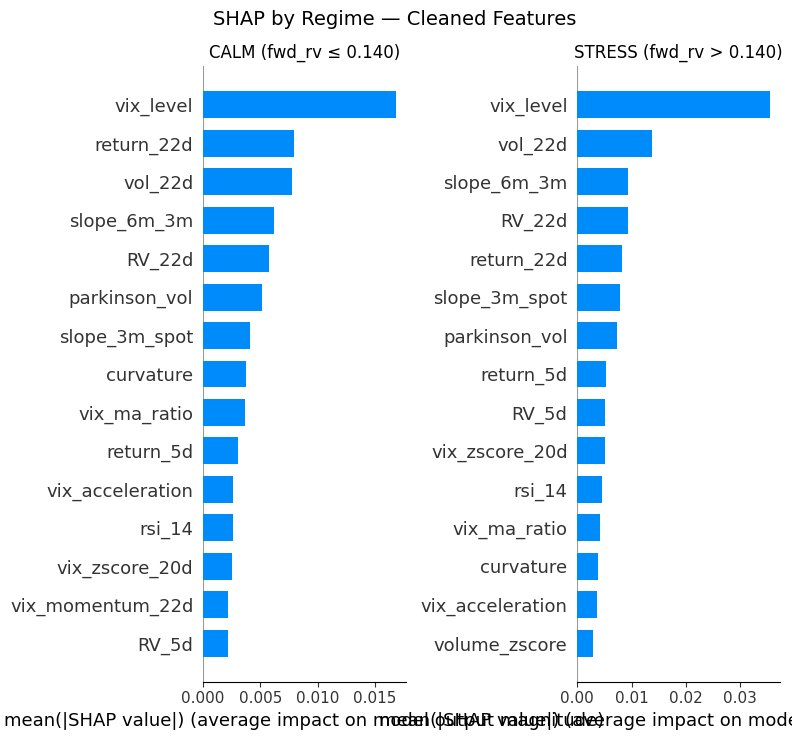

In [ ]:
# ── SHAP on cleaned feature set ──
explainer = shap.TreeExplainer(xgb_reg_final)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

median_rv = y_test_reg.median()
calm = y_test_reg <= median_rv
stress = y_test_reg > median_rv

plt.sca(axes[0])
shap.summary_plot(shap_values[calm.values], X_test[calm],
                  plot_type="bar", show=False, max_display=15)
axes[0].set_title(f"CALM (fwd_rv ≤ {median_rv:.3f})")

plt.sca(axes[1])
shap.summary_plot(shap_values[stress.values], X_test[stress],
                  plot_type="bar", show=False, max_display=15)
axes[1].set_title(f"STRESS (fwd_rv > {median_rv:.3f})")

plt.suptitle("SHAP by Regime — Cleaned Features", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ══════════════════════════════════════════════════════════════════
# LSTM AUTOENCODER — Regime Detection (P1 Architecture)
# ══════════════════════════════════════════════════════════════════
# This learns a compressed latent representation of the volatility
# regime. The latent trajectory features (velocity, acceleration,
# distance to crisis centroids) become inputs to the meta-model.

SEQUENCE_LEN = 30     # days per input sequence
LATENT_DIM = 8        # bottleneck dimension
HIDDEN_DIM = 32       # LSTM hidden size
BATCH_SIZE = 64
EPOCHS = 50
LR = 1e-3

# Use P1-relevant features for the autoencoder
ae_feature_cols = [
    "vix_level", "slope_3m_spot", "slope_6m_3m", "curvature",
    "contango_flag", "vix_1d_change", "vix_zscore_20d", "vix_ma_ratio",
    "RV_1d", "RV_5d", "RV_22d", "parkinson_vol",
]
ae_feature_cols = [c for c in ae_feature_cols if c in feat.columns]

print(f"Autoencoder input features ({len(ae_feature_cols)}): {ae_feature_cols}")


Autoencoder input features (12): ['vix_level', 'slope_3m_spot', 'slope_6m_3m', 'curvature', 'contango_flag', 'vix_1d_change', 'vix_zscore_20d', 'vix_ma_ratio', 'RV_1d', 'RV_5d', 'RV_22d', 'parkinson_vol']


In [ ]:
# ── Dataset: sliding windows ──
class VolSequenceDataset(Dataset):
    """Sliding window dataset for the LSTM autoencoder."""
    def __init__(self, data: np.ndarray, seq_len: int):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        return torch.FloatTensor(x)


# ── Model ──
class LSTMAutoencoder(nn.Module):
    """
    Encoder: LSTM reads the sequence, final hidden state = latent vector.
    Decoder: LSTM reconstructs the sequence from the latent vector.
    """
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.enc_to_latent = nn.Linear(hidden_dim, latent_dim)

        self.latent_to_dec = nn.Linear(latent_dim, hidden_dim)
        self.decoder_lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, input_dim)

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

    def encode(self, x):
        # x: (batch, seq_len, input_dim)
        _, (h_n, _) = self.encoder_lstm(x)
        # h_n: (1, batch, hidden_dim)
        latent = self.enc_to_latent(h_n.squeeze(0))
        return latent  # (batch, latent_dim)

    def decode(self, latent, seq_len):
        # Repeat latent vector as initial hidden state
        h_0 = self.latent_to_dec(latent).unsqueeze(0)
        c_0 = torch.zeros_like(h_0)
        # Feed zeros as decoder input (reconstruction from latent only)
        decoder_input = torch.zeros(latent.size(0), seq_len, self.input_dim).to(latent.device)
        out, _ = self.decoder_lstm(decoder_input, (h_0, c_0))
        return self.output_layer(out)

    def forward(self, x):
        latent = self.encode(x)
        recon = self.decode(latent, x.size(1))
        return recon, latent

print("Model and Dataset classes defined.")


Model and Dataset classes defined.


Training sequences: 2992
Sequence shape: (30, 12)
Device: cpu
  Epoch  10/50  Loss: 0.561047
  Epoch  20/50  Loss: 0.438478
  Epoch  30/50  Loss: 0.407631
  Epoch  40/50  Loss: 0.394523
  Epoch  50/50  Loss: 0.386977


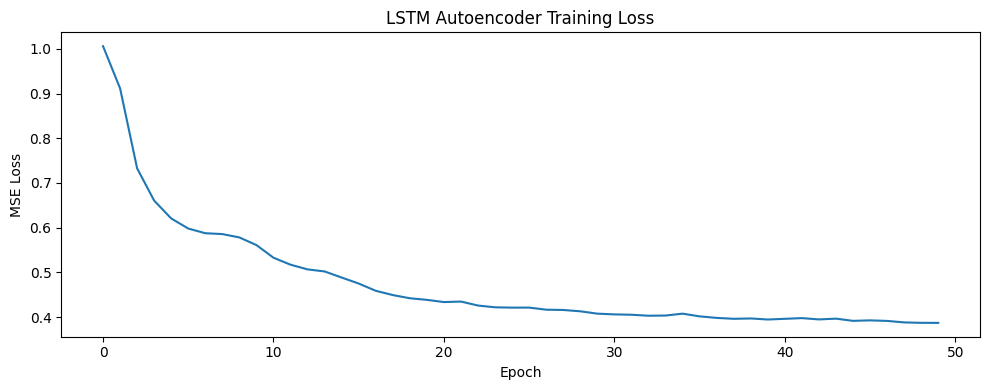

In [ ]:
# ── Prepare data ──
# Scale features
ae_scaler = StandardScaler()
ae_train_raw = feat.loc[feat.index < "2020-01-01", ae_feature_cols]
ae_all_raw = feat[ae_feature_cols]

ae_scaler.fit(ae_train_raw)
ae_train_scaled = ae_scaler.transform(ae_train_raw)
ae_all_scaled = ae_scaler.transform(ae_all_raw)

train_dataset = VolSequenceDataset(ae_train_scaled, SEQUENCE_LEN)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Training sequences: {len(train_dataset)}")
print(f"Sequence shape: ({SEQUENCE_LEN}, {len(ae_feature_cols)})")

# ── Train ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = LSTMAutoencoder(
    input_dim=len(ae_feature_cols),
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

losses = []
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        recon, latent = model(batch)
        loss = criterion(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch.size(0)
    epoch_loss /= len(train_dataset)
    losses.append(epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS}  Loss: {epoch_loss:.6f}")

plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Autoencoder Training Loss")
plt.tight_layout()
plt.show()


In [ ]:
# ══════════════════════════════════════════════════════════════════
# EXTRACT LATENT FEATURES
# ══════════════════════════════════════════════════════════════════

model.eval()
all_dataset = VolSequenceDataset(ae_all_scaled, SEQUENCE_LEN)
all_loader = DataLoader(all_dataset, batch_size=256, shuffle=False)

latent_vectors = []
recon_errors = []

with torch.no_grad():
    for batch in all_loader:
        batch = batch.to(device)
        recon, latent = model(batch)
        latent_vectors.append(latent.cpu().numpy())
        # Per-sequence reconstruction error
        err = ((recon - batch) ** 2).mean(dim=(1, 2)).cpu().numpy()
        recon_errors.append(err)

latent_vectors = np.concatenate(latent_vectors, axis=0)
recon_errors = np.concatenate(recon_errors, axis=0)

# Align with date index (each latent corresponds to the LAST day of its window)
latent_dates = feat.index[SEQUENCE_LEN - 1:][:len(latent_vectors)]

latent_df = pd.DataFrame(
    latent_vectors,
    index=latent_dates,
    columns=[f"latent_{i}" for i in range(LATENT_DIM)],
)
latent_df["recon_error"] = recon_errors

# ── Trajectory features ──
# Velocity: how fast the latent state moves day-to-day
latent_coords = latent_df[[f"latent_{i}" for i in range(LATENT_DIM)]]
velocity = np.sqrt(((latent_coords.diff()) ** 2).sum(axis=1))
latent_df["latent_velocity"] = velocity

# Acceleration: change in velocity
latent_df["latent_acceleration"] = velocity.diff()

# Distance from crisis centroid (use 2008 and 2020 latent vectors)
crisis_mask = latent_df.index.year.isin([2008, 2020])
if crisis_mask.sum() > 0:
    crisis_centroid = latent_coords[crisis_mask].mean().values
    distances = np.sqrt(((latent_coords.values - crisis_centroid) ** 2).sum(axis=1))
    latent_df["crisis_distance"] = distances

print(f"Latent features: {latent_df.shape}")
print(f"Columns: {list(latent_df.columns)}")
print(f"\nDate range: {latent_df.index.min().date()} to {latent_df.index.max().date()}")


Latent features: (4477, 12)
Columns: ['latent_0', 'latent_1', 'latent_2', 'latent_3', 'latent_4', 'latent_5', 'latent_6', 'latent_7', 'recon_error', 'latent_velocity', 'latent_acceleration', 'crisis_distance']

Date range: 2008-02-13 to 2025-11-26


Running t-SNE (this takes ~30 seconds)...


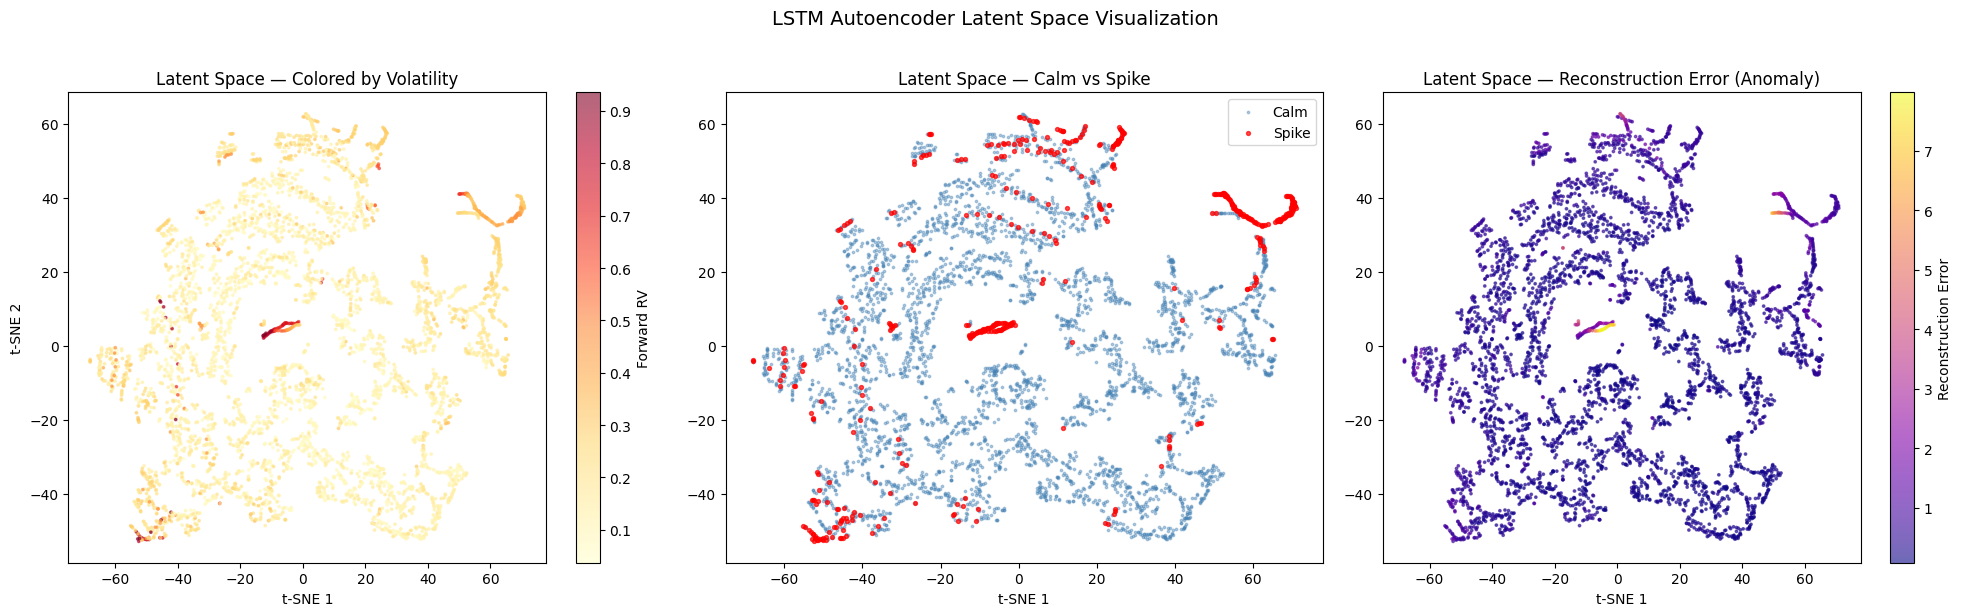

In [ ]:
# ── Visualize latent space ──
from sklearn.manifold import TSNE

# Color by forward RV (align dates)
aligned_rv = feat.loc[latent_df.index, "fwd_rv_22d"]
aligned_spike = feat.loc[latent_df.index, "spike_label"]

# t-SNE for visualization (2D projection of 8D latent space)
print("Running t-SNE (this takes ~30 seconds)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
latent_2d = tsne.fit_transform(latent_coords.values)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Colored by volatility level
ax = axes[0]
sc = ax.scatter(latent_2d[:, 0], latent_2d[:, 1],
                c=aligned_rv.values, cmap="YlOrRd", s=3, alpha=0.6)
plt.colorbar(sc, ax=ax, label="Forward RV")
ax.set_title("Latent Space — Colored by Volatility")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

# Colored by spike label
ax = axes[1]
calm_pts = latent_2d[aligned_spike.values == 0]
spike_pts = latent_2d[aligned_spike.values == 1]
ax.scatter(calm_pts[:, 0], calm_pts[:, 1], c="steelblue", s=3, alpha=0.4, label="Calm")
ax.scatter(spike_pts[:, 0], spike_pts[:, 1], c="red", s=8, alpha=0.7, label="Spike")
ax.set_title("Latent Space — Calm vs Spike")
ax.legend()
ax.set_xlabel("t-SNE 1")

# Reconstruction error
ax = axes[2]
sc = ax.scatter(latent_2d[:, 0], latent_2d[:, 1],
                c=latent_df["recon_error"].values, cmap="plasma", s=3, alpha=0.6)
plt.colorbar(sc, ax=ax, label="Reconstruction Error")
ax.set_title("Latent Space — Reconstruction Error (Anomaly)")
ax.set_xlabel("t-SNE 1")

plt.suptitle("LSTM Autoencoder Latent Space Visualization", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


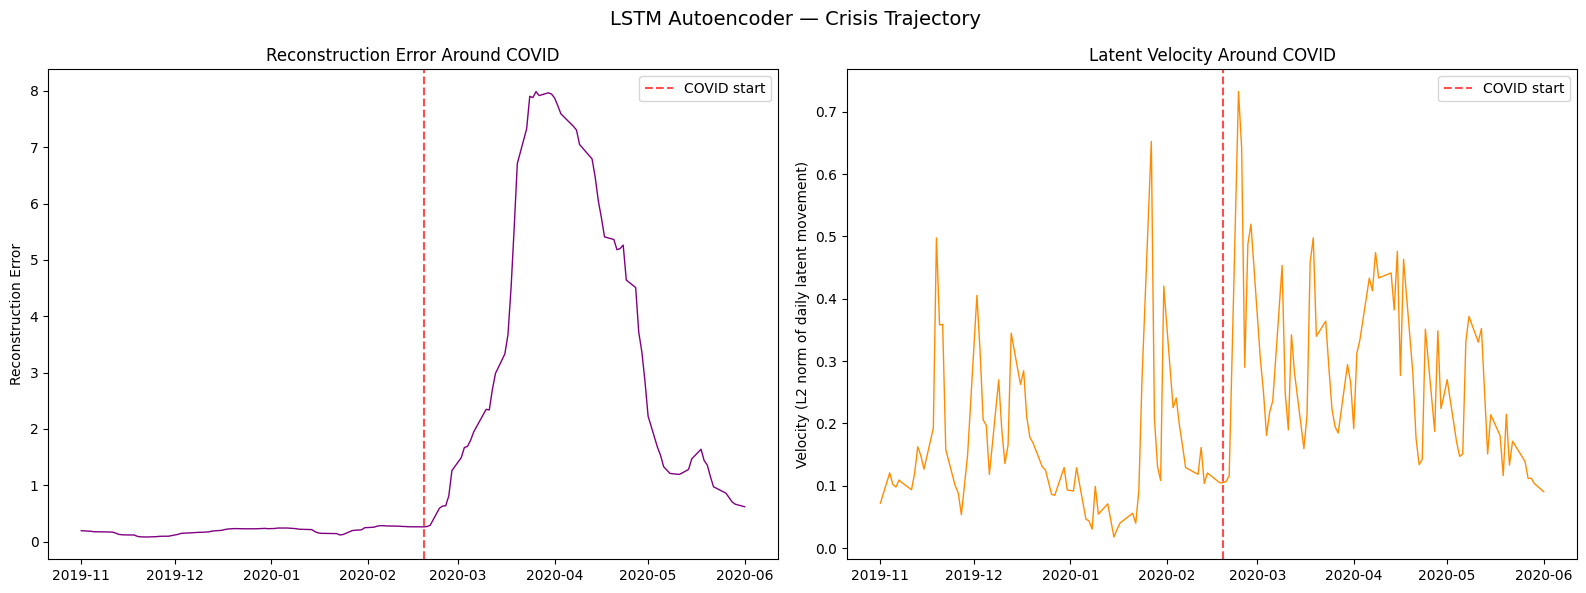


Key question: does reconstruction error or latent velocity spike
BEFORE Feb 19, 2020? If so, the autoencoder provides early warning.


In [ ]:
# ── Trajectory through crisis ──
# Show latent space trajectory during COVID (Feb-Apr 2020)

covid_mask = (latent_df.index >= "2020-02-01") & (latent_df.index <= "2020-05-01")
pre_covid = (latent_df.index >= "2019-11-01") & (latent_df.index < "2020-02-01")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Reconstruction error time series around COVID
ax = axes[0]
plot_mask = (latent_df.index >= "2019-11-01") & (latent_df.index <= "2020-06-01")
plot_data = latent_df.loc[plot_mask]
ax.plot(plot_data.index, plot_data["recon_error"], linewidth=1, color="purple")
ax.axvline(pd.Timestamp("2020-02-19"), color="red", linestyle="--", alpha=0.7, label="COVID start")
ax.set_title("Reconstruction Error Around COVID")
ax.set_ylabel("Reconstruction Error")
ax.legend()

# Velocity through crisis
ax = axes[1]
ax.plot(plot_data.index, plot_data["latent_velocity"], linewidth=1, color="darkorange")
ax.axvline(pd.Timestamp("2020-02-19"), color="red", linestyle="--", alpha=0.7, label="COVID start")
ax.set_title("Latent Velocity Around COVID")
ax.set_ylabel("Velocity (L2 norm of daily latent movement)")
ax.legend()

plt.suptitle("LSTM Autoencoder — Crisis Trajectory", fontsize=14)
plt.tight_layout()
plt.show()

print("\nKey question: does reconstruction error or latent velocity spike")
print("BEFORE Feb 19, 2020? If so, the autoencoder provides early warning.")


Meta-model features: 36 (24 original + 12 latent)

META-MODEL COMPARISON (test: 2020+)
                                     MSE      MAE      AUC
Model                                                     
HAR-RV Linear (3 feat)          0.010815 0.056973 0.827128
XGBoost Baseline (24 feat)      0.010136 0.055317 0.787139
XGBoost + Autoencoder (36 feat) 0.010204 0.056573 0.762443

Autoencoder latent features added: latent_0..7, recon_error, latent_velocity, latent_acceleration, crisis_distance


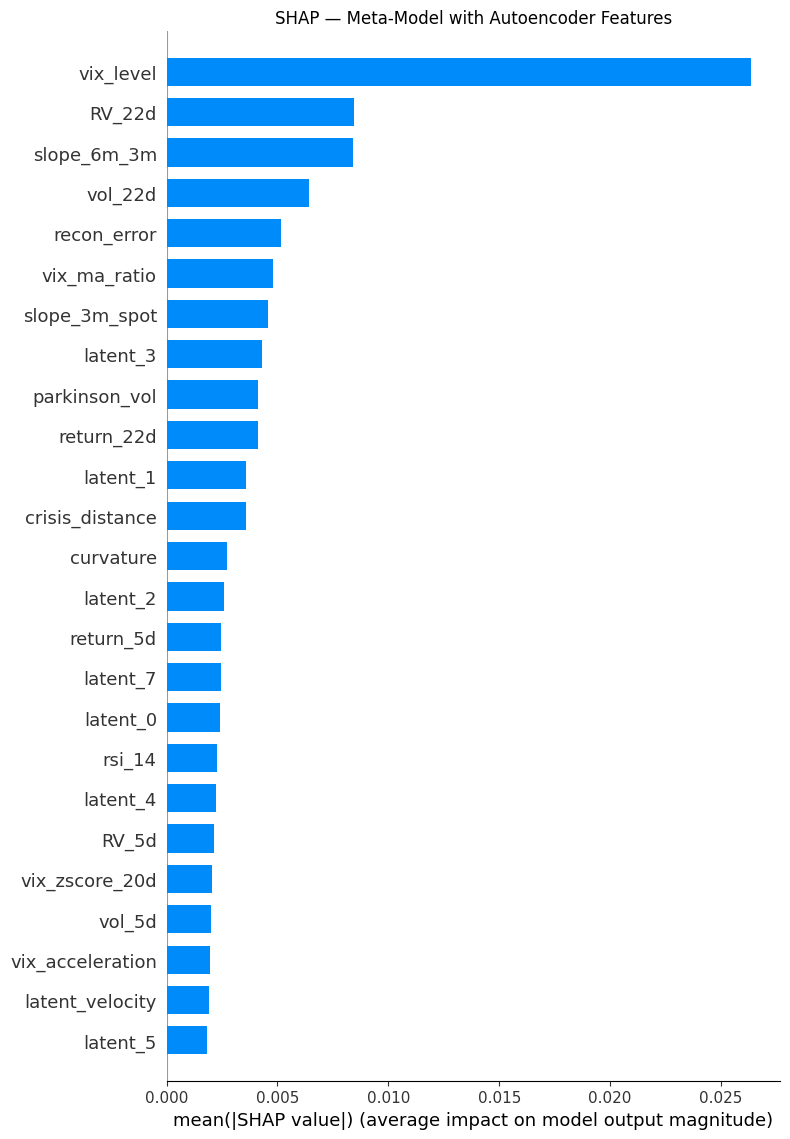

In [ ]:
# ══════════════════════════════════════════════════════════════════
# META-MODEL V2 — XGBoost with Autoencoder Latent Features
# ══════════════════════════════════════════════════════════════════

# Merge latent features with original features
meta_features = feat[feature_cols].join(latent_df, how="inner")
meta_features = meta_features.join(feat[target_cols], how="inner").dropna()

meta_target_cols = ["fwd_rv_22d", "spike_label"]
meta_feature_cols = [c for c in meta_features.columns if c not in meta_target_cols]

print(f"Meta-model features: {len(meta_feature_cols)} ({len(feature_cols)} original + {len(meta_feature_cols) - len(feature_cols)} latent)")

# Split
m_train = meta_features[meta_features.index < "2020-01-01"]
m_test = meta_features[meta_features.index >= "2020-01-01"]

mX_train = m_train[meta_feature_cols]
my_train_reg = m_train["fwd_rv_22d"]
mX_test = m_test[meta_feature_cols]
my_test_reg = m_test["fwd_rv_22d"]
my_test_cls = m_test["spike_label"]

# Train meta-model with latent features
xgb_meta = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=0,
)
xgb_meta.fit(mX_train, my_train_reg)
meta_pred = xgb_meta.predict(mX_test)

meta_mse = mean_squared_error(my_test_reg, meta_pred)
meta_mae = mean_absolute_error(my_test_reg, meta_pred)
meta_auc = roc_auc_score(my_test_cls, meta_pred)

# Compare with baseline (no latent features)
xgb_base = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=0,
)
xgb_base.fit(m_train[feature_cols], my_train_reg)
base_pred = xgb_base.predict(m_test[feature_cols])

base_mse = mean_squared_error(my_test_reg, base_pred)
base_auc = roc_auc_score(my_test_cls, base_pred)

# HAR baseline
har = LinearRegression().fit(m_train[har_cols], my_train_reg)
har_pred = har.predict(m_test[har_cols])
h_mse = mean_squared_error(my_test_reg, har_pred)
h_auc = roc_auc_score(my_test_cls, har_pred)

print("\n" + "=" * 70)
print("META-MODEL COMPARISON (test: 2020+)")
print("=" * 70)
comp = pd.DataFrame({
    "Model": [
        "HAR-RV Linear (3 feat)",
        f"XGBoost Baseline ({len(feature_cols)} feat)",
        f"XGBoost + Autoencoder ({len(meta_feature_cols)} feat)",
    ],
    "MSE": [h_mse, base_mse, meta_mse],
    "MAE": [mean_absolute_error(my_test_reg, har_pred),
            mean_absolute_error(my_test_reg, base_pred), meta_mae],
    "AUC": [h_auc, base_auc, meta_auc],
}).set_index("Model")
print(comp.to_string(float_format="%.6f"))

print(f"\nAutoencoder latent features added: latent_0..{LATENT_DIM-1}, "
      f"recon_error, latent_velocity, latent_acceleration, crisis_distance")

# SHAP on the meta-model to see if latent features matter
explainer_meta = shap.TreeExplainer(xgb_meta)
shap_meta = explainer_meta.shap_values(mX_test)

plt.figure(figsize=(10, 10))
shap.summary_plot(shap_meta, mX_test, plot_type="bar", show=False, max_display=25)
plt.title("SHAP — Meta-Model with Autoencoder Features")
plt.tight_layout()
plt.show()
